---
tags: [algorithm, finance, simulation]
---

# 量子振幅推定を用いたオプションプライシング

ゲート型量子コンピュータ上で実行する量子振幅推定は、様々な応用が提案されています。
その中でも、金融工学のオプションプライシングは、その代表的な応用例の一つです。
これまでオプションプライシングには古典モンテカルロ法が用いられてきましたが、これは目標精度 $\epsilon$ を達成するための必要なオラクルの呼び出し回数が $\mathcal{O} (\epsilon^{-2})$ でした。
これに対し、量子振幅推定は $\mathcal{O} (\epsilon^{-1})$ で済み、2次の高速化をもたらすアルゴリズムであることが知られています。
そこで本記事では、[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)で提案された、量子振幅推定によるオプションおよびオプションポートフォリオプライシング手法の理解と実装についてまとめました。オプションプライシングの例を通して、Qamomileの使い方を学びましょう。

In [10]:
# Install the latest Qamomile through pip! 
#!pip install qamomile

In [11]:
import numpy as np
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt

import qamomile.circuit as qmc
from qamomile.circuit.stdlib import amplitude_encoding
from qamomile.qiskit import QiskitTranspiler

## 背景

最初に、この記事で出てくる用語についてまとめておきましょう。

* アセット (原資産): 株式など、オプションの対象となる金融商品
* オプション: 将来の決められた時点 (満期) に、決められた価格 (権利行使価格) でアセットを売買する権利
* ペイオフ: 満期時点でのオプションの価値

### 問題: オプションプライシング

金融リスクの計算は、大きな需要があります。
モンテカルロ (MC) 計算はその中心的な計算手法であり、Value at Risk (VaR) の推定や店頭デリバティブの価格決定など、幅広く用いられています。
しかし収束が悪く、その誤差は $\varepsilon = \mathcal{O} (M^{-1/2})$ で減衰するという欠点があります。
ここで $M$ はサンプル数です。  
対象となる確率分布が量子状態として準備される場合、量子振幅推定 (QAE) により、期待値などの統計量を $\mathcal{O} (M^{-1})$ で推定できることが知られています。
これは先ほどの古典MCに対し、二次の高速化をもたらすことがわかります。  
[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)では、先行研究のプライシング手法を拡張した量子回路実装を示しました。

### 先行研究

モンテカルロプライシングの量子アルゴリズムの理論的枠組みを示した先行研究として、[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)があります。
この論文は、プライシング計算において、古典に対し2次高速化が得られることを理論的に示しました。
そして、特にヨーロピアンオプションとアジアンオプションに対して数値シミュレーションを行い、その有効性を示しました。
しかし、その成果は理論的な枠組みの提示と数値シミュレーションに留まり、実機での実行は示されていません。  
もう一つの重要な先行研究として、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6)があります。
これはプライシングに対してではなく、VaR や Conditional Value at Risk (CVaR) に QAE を適用した研究です。
先ほどの[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)のペイオフ計算を改良し、必要量子ビット数・ゲート数の大幅な削減に成功しました。  
そこで[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)では、[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321)のペイオフ計算手法をオプションプライシングに拡張し、NISQフレンドリーな実装を示しました。

## アルゴリズム: NISQでのオプションプライシング計算

### ペイオフの計算

QAE ではグローバー演算子 $\mathcal{Q}$ を $k$ 回繰り返すことで、測定確率が
$\sin^2((2k+1)\theta_a)$ という既知の関数形で変化します。
これにより、少ない測定回数でも $\theta_a$ を高精度に推定することが可能になります。  
今、アセットの価格を $S_i$とし、それが起こる確率を $p_i$ としましょう。
演算子 $\mathcal{A}$ が

$$
\mathcal{A} \vert 0 \rangle_{n+1} 
= \sum_{i=0}^{2^n - 1} \sqrt{1-f(S_i)} \sqrt{p_i} \vert S_i \rangle \vert 0 \rangle + \sum_{i=0}^{2^n - 1} \sqrt{f(S_i)} \sqrt{p_i} \vert S_i \rangle \vert 1 \rangle \tag{1}
$$

のような状態を作れるとすると、$\vert 1 \rangle$ の振幅は $a = \mathbb{E}[f(S)]$ となり、QAE によりペイオフの期待値を計算できることがわかります。
[Rebentrost et al. (2018)](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.98.022321) は補助レジスタにペイオフをバイナリ表現で格納する手法を提案しましたが、量子ビット数と回路 depth が増大する問題がありました。
そこで [Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/) では、[Woerner & Egger (2019)](https://www.nature.com/articles/s41534-019-0130-6) の軽量な $R_y$ 手法を採用しました。

### 平均値への適用と $c$ パラメータ

$\sin^2$ の導関数が最大となる $\pi/4$ の周りで展開するために、目標振幅角を

$$
\tilde{f}(i) = 2 \frac{f(i) - f_\mathrm{min}}{f_\mathrm{max} - f_\mathrm{min}} - 1, \qquad
\alpha(i) = c\tilde{f}(i) + \frac{\pi}{4} \tag{2}
$$

と定義します ($c \in [0, 1]$ はスケーリングパラメータ)。
このときペイオフ量子ビットが $\vert 1 \rangle$ となる確率は

$$
P_1 \approx \frac{1}{2} + c\,\mathbb{E}[\tilde{f}] + \mathcal{O}(c^3) \tag{3}
$$

となり、$P_1$ を推定すれば既知の $c, f_\mathrm{min}, f_\mathrm{max}$ から $\mathbb{E}[f(S)]$ を算出できます。  
$P_1$ の推定誤差を $\delta P_1$ とすると、$\mathbb{E}[\tilde{f}] \approx (P_1 - 1/2)/c$ より
推定誤差は $\delta P_1/c$ に増幅されます。
$c$ を小さくするとこの誤差増幅が大きくなり、逆に大きくすると
近似バイアス $\mathcal{O}(c^2)$ が増大します。
このトレードオフから収束率は $\mathcal{O}(M^{-2/3})$ となります。
完全な二次高速化には至りませんが、依然として古典 MC の $\mathcal{O}(M^{-1/2})$ を凌駕します。  
以下の実装では、位相推定を用いない軽量な最尤振幅推定(MLAE)を採用しています。

### コールオプションへの応用

コールオプションのペイオフ $f_C(S_T) = \max(0, S_T - K)$ は $K$ を境に折れ曲がる区分線形関数です。
本実装では均一制御回転(UCR-Y)を用い、各格子点 $S_i$ に対して

$$
\alpha(S_i) = \frac{\pi}{4} - c + \frac{2c\,\max(S_i - K,\,0)}{S_\mathrm{max} - K} \tag{4}
$$

という目標振幅角を直接適用します。
$S < K$ では定数角 $\pi/4 - c$、$S \geq K$ では線形増加という区分線形構造を、正確に符号化することができます。

## Qamomileによる実装

### 分布の準備

それでは、[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/)で示された実装を見ていきましょう。
ここではまず、幾何ブラウン運動下にある満期 $S_T$ の対数正規分布を離散化したものを準備し、これを株価のデータとします。

In [20]:
n_qubits = 4
S0, K, r, sigma, T = 2.0, 1.9, 0.05, 0.4, 40 / 365
mu  = (r - 0.5 * sigma**2) * T
std = sigma * np.sqrt(T)
S_min = float(S0 * np.exp(mu - 3 * std))
S_max = float(S0 * np.exp(mu + 3 * std))
S_grid = np.linspace(S_min, S_max, 2**n_qubits)

def lognpdf(S):
    return (np.exp(-(np.log(S / S0) - mu)**2 / (2 * std**2))
            / (S * std * np.sqrt(2 * np.pi)))

probs = lognpdf(S_grid)
probs /= probs.sum()
amps  = np.sqrt(probs)   # Möttönen エンコード用の振幅 √p_i

c     = 0.25             # スケーリングパラメータ
F_max = float(S_max - K)

# ── 目標振幅角 ──
payoff       = np.maximum(S_grid - K, 0.0)
alpha_target = np.pi / 4 - c + 2 * c * payoff / F_max   # shape: (2^n,)

# ── 参照値 ──
# exact_E_f: 数値積分による厳密な期待ペイオフ(離散格子上の積分値)
exact_E_f  = float(np.sum(probs * payoff))
exact_fair = np.exp(-r * T) * exact_E_f

# P1 の厳密値: Σ_i p_i sin²(α_i)  ← 線形近似を使わない
P1_exact  = float(np.sum(probs * np.sin(alpha_target)**2))

# P1 の近似値
E_ftilde  = 2 * exact_E_f / F_max - 1
P1_approx = c * E_ftilde + 0.5

print(f"期待ペイオフ(数値積分):     {exact_E_f:.6f}")
print(f"フェアバリュー(参照値):     {exact_fair:.6f}")
print(f"P1 厳密値:                 {P1_exact:.6f}")
print(f"P1 近似値(線形近似):        {P1_approx:.6f}")
print(f"P1 近似誤差:               {abs(P1_exact - P1_approx):.6f}")

期待ペイオフ(数値積分):     0.167010
フェアバリュー(参照値):     0.166098
P1 厳密値:                 0.333988
P1 近似値(線形近似):        0.328358
P1 近似誤差:               0.005631


### ペイオフ演算子の実装

アルゴリズムの部分で示したように、コールオプションのペイオフ $f(S) = \max(S-K, 0)$ は $K$ で折れ曲がる区分線形関数です。
そのため、格子点ごとに異なる目標振幅角

$$
\alpha(S_i) = \frac{\pi}{4} - c + \frac{2c\,\max(S_i - K,\, 0)}{S_\mathrm{max} - K}
$$

をペイオフ量子ビットに適用する必要があります。
UCR-Y は各基底状態 $\vert i \rangle$ に対して独立な振幅角 $\alpha(S_i)$ を適用できるため、$K$ を境とした区分線形構造を正確に符号化することができます。
以下では、この UCR-Y を $R_y$ と CNOT のみで分解する実装を示しています。

In [13]:
# ── UCR-Y ゲートリストを事前計算(Python レベルの再帰) ──
def _ucry_recursive(angles, ctrl_indices, tgt_index, gates):
    """UCR-Y の再帰的 demultiplexing。ゲートを ('ry'|'cx', ...) のリストに積む。"""
    if len(ctrl_indices) == 0:
        if abs(angles[0]) > 1e-12:
            gates.append(('ry', tgt_index, angles[0]))
        return
    m = len(angles) // 2
    a = [(angles[i] + angles[i + m]) / 2 for i in range(m)]
    b = [(angles[i] - angles[i + m]) / 2 for i in range(m)]
    _ucry_recursive(a, ctrl_indices[:-1], tgt_index, gates)
    gates.append(('cx', ctrl_indices[-1], tgt_index))
    _ucry_recursive(b, ctrl_indices[:-1], tgt_index, gates)
    gates.append(('cx', ctrl_indices[-1], tgt_index))

# UCR-Y の回転角 = 2 × 振幅角(qmc.ry の定義 Ry(θ)|0⟩ = cos(θ/2)|0⟩ + sin(θ/2)|1⟩ より)
ucry_gates = []
_ucry_recursive(
    (2 * alpha_target).tolist(),   # 振幅角 α を 2 倍して渡す
    list(range(n_qubits)),         # コントロール: q_S[0..n-1]
    n_qubits,                      # ターゲット: payoff qubit (インデックス n_qubits)
    ucry_gates
)

# UCR-Y の随伴ゲートリスト(逆順 + Ry 角度反転)
ucry_inv_gates = []
for gate in reversed(ucry_gates):
    if gate[0] == 'ry':
        ucry_inv_gates.append(('ry', gate[1], -gate[2]))
    else:  # CNOT は自己逆
        ucry_inv_gates.append(gate)

print(f"UCR-Y ゲート数: {len(ucry_gates)} (Ry + CNOT)")

# UCR-Y を @qkernel 内から呼ぶための関数 
def _make_ucry_func(gate_list):
    """UCR-Y ゲートリストを順に適用する関数を返す。"""
    def apply_ucry(q_S, q_p):
        for gate in gate_list:
            if gate[0] == 'ry':
                q_p = qmc.ry(q_p, gate[2])
            else:                                       # 'cx': CNOT
                q_S[gate[1]], q_p = qmc.cx(q_S[gate[1]], q_p)
        return q_S, q_p
    return apply_ucry

apply_payoff_ucr     = _make_ucry_func(ucry_gates)      # F  (ペイオフ回路)
apply_payoff_ucr_inv = _make_ucry_func(ucry_inv_gates)  # F† (ペイオフ随伴)

UCR-Y ゲート数: 46 (Ry + CNOT)


### 分布の読み込みの実装

そして先ほど準備した株価データを読み込む演算と、そのエルミート演算を実装しましょう。
Qamomile には、振幅符号化の関数が標準で備わっています。

In [14]:
# ── P_X と P_X†(分布ロードとその随伴) ──
@qmc.qkernel
def load_distribution(q: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    """P_X: 対数正規分布を Möttönen でロード"""
    q = amplitude_encoding(q, amps.tolist())
    return q

# qmc.inverse で随伴を自動生成
load_distribution_inv = qmc.inverse(load_distribution)

この分布読み込みと、(21)式にあるように制御 $R_y$ ゲートである $\mathrm{CR}_y$ を施すことで、コールオプションのペイオフをペイオフ量子ビット振幅に変換する回路を構築します。
`num_shots` の回数だけ測定を行い、ペイオフ量子ビットが $\vert 1 \rangle$ になる確率 $P_1$ を推定します。
そして(13)式から近似式 $P_1 \approx \frac{1}{2} + c\mathbb{E}[\tilde{f}]$ から、ペイオフの期待値を算出します。
ここで算出された $P_1$ の値が理論値と近い値となることを示すことで、ペイオフ回路が正しく機能していることを確認しています。

In [15]:
@qmc.qkernel
def payoff_call() -> qmc.Bit:
    q_S = qmc.qubit_array(n_qubits, "q_S")
    q_p = qmc.qubit(name="q_p")

    # (1) 分布ロード: P_X
    q_S = load_distribution(q_S)

    # (2) UCR-Y ペイオフ回路: F
    #     |i⟩|0⟩ → |i⟩(cos α(i)|0⟩ + sin α(i)|1⟩)
    #     α(i) = π/4 - c + 2c*max(S_i-K, 0) / (S_max-K)
    #     S < K: 定数角 π/4 - c  /  S >= K: 線形増加
    q_S, q_p = apply_payoff_ucr(q_S, q_p)

    _ = qmc.measure(q_S)
    return qmc.measure(q_p)


num_shots      = 4096
transpiler_qmc = QiskitTranspiler()
exe_k0 = transpiler_qmc.transpile(payoff_call)   # バインディング不要
res_k0 = exe_k0.sample(transpiler_qmc.executor(), shots=num_shots).result()

ones_k0 = 0
for q, num in res_k0.results:
    if q == 1:
        ones_k0 += num
P1_k0 = ones_k0 / num_shots

print(f"\n[Qamomile k=0]")
print(f"P1 測定値:              {P1_k0:.4f}")
print(f"P1 厳密値(参照):     {P1_exact:.4f}")
print(f"P1 近似値:          {P1_approx:.4f}")
print("→ 測定値が厳密値に近ければペイオフ回路は正しく動いています")


[Qamomile k=0]
P1 測定値:           0.3408
P1 厳密値(参照):     0.3340
P1 近似値(式5, 参照):0.3284
→ 測定値が厳密値に近ければペイオフ回路は正しく動いています


### 量子振幅推定の実装

振幅推定のためのGrover演算子 $\mathcal{Q} = \mathcal{A} \mathcal{S}_0 \mathcal{A}^\dagger \mathcal{S}_\chi$ を $k$ 回適用する量子回路を構築しましょう。
$k$ 回適用した量子状態において、ペイオフ量子ビットが $\vert 1 \rangle$ になる確率 $P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$ を求めます。

In [ ]:
def build_Ak_kernel(k: int):
    n_anc = max(0, n_qubits - 2)

    if n_anc == 0:
        # n_qubits <= 2: アンシラ不要
        @qmc.qkernel
        def Ak() -> qmc.Bit:
            q_S = qmc.qubit_array(n_qubits, "q_S")
            q_p = qmc.qubit(name="q_p")

            # ── A = P_X · F ──
            q_S = load_distribution(q_S)
            q_S, q_p = apply_payoff_ucr(q_S, q_p)

            # ── Q を k 回適用 ──
            for _ in range(k):

                # S_χ: payoff qubit が |1⟩ のとき位相 -1
                q_p = qmc.z(q_p)

                # A† = F† · P_X†
                q_S, q_p = apply_payoff_ucr_inv(q_S, q_p)
                q_S = load_distribution_inv(q_S)

                # S₀: |0…0⟩ のとき位相 -1
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)
                if n_qubits == 1:
                    q_S[0], q_p = qmc.cz(q_S[0], q_p)
                elif n_qubits == 2:
                    q_p = qmc.h(q_p)
                    q_S[0], q_S[1], q_p = qmc.ccx(q_S[0], q_S[1], q_p)
                    q_p = qmc.h(q_p)
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)

                # A
                q_S = load_distribution(q_S)
                q_S, q_p = apply_payoff_ucr(q_S, q_p)

            _ = qmc.measure(q_S)
            return qmc.measure(q_p)

    else:
        # n_qubits >= 3: S₀ の MCZ に Toffoli ラダーとアンシラを使用
        @qmc.qkernel
        def Ak() -> qmc.Bit:
            q_S = qmc.qubit_array(n_qubits, "q_S")
            q_p = qmc.qubit(name="q_p")
            anc = qmc.qubit_array(n_anc, "anc")

            # ── A = P_X · F ──
            q_S = load_distribution(q_S)
            q_S, q_p = apply_payoff_ucr(q_S, q_p)

            # ── Q を k 回適用 ──
            for _ in range(k):

                # S_χ
                q_p = qmc.z(q_p)

                # A† = F† · P_X†
                q_S, q_p = apply_payoff_ucr_inv(q_S, q_p)
                q_S = load_distribution_inv(q_S)

                # S₀: Toffoli ラダー(n_qubits >= 3)
                # アンシラに桁上がりを伝播(前半) → 最終段 → アンシラをゼロ戻し(後半)
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)
                q_p = qmc.h(q_p)
                # 前半
                q_S[0], q_S[1], anc[0] = qmc.ccx(q_S[0], q_S[1], anc[0])
                for i in qmc.range(1, n_qubits - 2):
                    anc[i-1], q_S[i+1], anc[i] = qmc.ccx(
                        anc[i-1], q_S[i+1], anc[i])
                # 最終段
                anc[n_qubits-3], q_S[n_qubits-1], q_p = qmc.ccx(
                    anc[n_qubits-3], q_S[n_qubits-1], q_p)
                # 後半(uncompute): 逆順
                for i in range(n_qubits - 3, 0, -1):
                    anc[i-1], q_S[i+1], anc[i] = qmc.ccx(
                        anc[i-1], q_S[i+1], anc[i])
                q_S[0], q_S[1], anc[0] = qmc.ccx(q_S[0], q_S[1], anc[0])
                q_p = qmc.h(q_p)
                q_S = qmc.x(q_S)
                q_p = qmc.x(q_p)

                # A
                q_S = load_distribution(q_S)
                q_S, q_p = apply_payoff_ucr(q_S, q_p)

            _ = qmc.measure(anc)
            _ = qmc.measure(q_S)
            return qmc.measure(q_p)

    return Ak


k_list      = [0, 1, 2, 4, 8, 16]
shots_per_k = 2048

transpiler_q = QiskitTranspiler()
h_list, N_list = [], []

# P1 の理論値には線形近似値ではなく厳密値を使用
theta_a_theory = np.arcsin(np.sqrt(max(0.0, min(1.0, P1_exact))))
print()
for k in k_list:
    kernel = build_Ak_kernel(k)
    exe    = transpiler_q.transpile(kernel)   # バインディング不要
    result = exe.sample(transpiler_q.executor(), shots=shots_per_k).result()

    ones = 0
    for q, num in result.results:
        if q == 1:
            ones += num
    h_list.append(ones)
    N_list.append(shots_per_k)
    P1_k  = ones / shots_per_k
    P1_th = np.sin((2*k + 1) * theta_a_theory)**2
    print(f"k={k:2d}: P1 測定={P1_k:.4f}  理論値(厳密)={P1_th:.4f}")


k= 0: P1 測定=0.3354  理論値(厳密)=0.3340
k= 1: P1 測定=0.9204  理論値(厳密)=0.9248
k= 2: P1 測定=0.0034  理論値(厳密)=0.0037
k= 4: P1 測定=0.4531  理論値(厳密)=0.4523
k= 8: P1 測定=0.7427  理論値(厳密)=0.7526


複数の $k$ での測定データ (二項分布) をベースに、$P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$ というモデルに対する最尤推定を実施しましょう。
これにより振幅角 $\theta_\alpha$ を推定し、さらに $P_1 = \sin^2 \theta_\alpha$ を計算します。
そしてこの $P_1$ からペイオフの期待値 $\mathbb{E}[f(S)]$ を計算し、無リスク金利で割り引くことで、オプションのフェアバリューを算出します。
最後に、古典モンテカルロ法から求めた参照値との比較を行っています。

In [17]:
# ============================================================
# 4. 最尤推定(MLE)
# ============================================================
def neg_log_lik(theta: float) -> float:
    """
    負の対数尤度:
      -Σ_k [h_k log sin²((2k+1)θ) + (N_k - h_k) log cos²((2k+1)θ)]
    """
    ll = 0.0
    for k, h, N in zip(k_list, h_list, N_list):
        s2 = float(np.clip(np.sin((2*k + 1) * theta)**2, 1e-12, 1 - 1e-12))
        ll += h * np.log(s2) + (N - h) * np.log(1 - s2)
    return -ll

opt       = minimize_scalar(neg_log_lik, bounds=(0, np.pi / 2), method='bounded')
theta_hat = opt.x
a_hat     = np.sin(theta_hat)**2

# P1 → E[f(S)] の逆算(式5 の線形近似を使用、近似バイアスは O(c²))
# E[f̃] ≈ (P1 - 1/2) / c, E[f] = F_max/2 * (E[f̃] + 1)
E_ftilde_hat = (a_hat - 0.5) / c
E_f_hat      = (E_ftilde_hat + 1) * F_max / 2
fair_hat     = np.exp(-r * T) * E_f_hat

print(f"\n===== 推定結果 =====")
print(f"推定 P1:          {a_hat:.6f}  "
      f"(厳密値 {P1_exact:.6f}, 近似値 {P1_approx:.6f})")
print(f"推定 E[f(S)]:     {E_f_hat:.6f}  (参照値 {exact_E_f:.6f})")
print(f"推定フェアバリュー: {fair_hat:.6f}  (参照値 {exact_fair:.6f})")
print(f"絶対誤差:          {abs(fair_hat - exact_fair):.6f}")


===== 推定結果 =====
推定 P1:          0.333628  (厳密値 0.333988, 近似値 0.328358)
推定 E[f(S)]:     0.178243  (参照値 0.167010)
推定フェアバリュー: 0.177269  (参照値 0.166098)
絶対誤差:          0.011171


対数尤度関数 $\log \mathcal{L} (\sin^2 \theta)$と、$P_1^{(k)}$ をプロットしてみましょう。
左図は対数尤度関数と、最尤推定値および古典MCによる理論値も示しています。
さらに右図は、$\theta_\alpha$ から得られる理論曲線 $P_1^{(k)} = \sin^2 ((2k+1) \theta_\alpha)$ も重ねて描画しています。

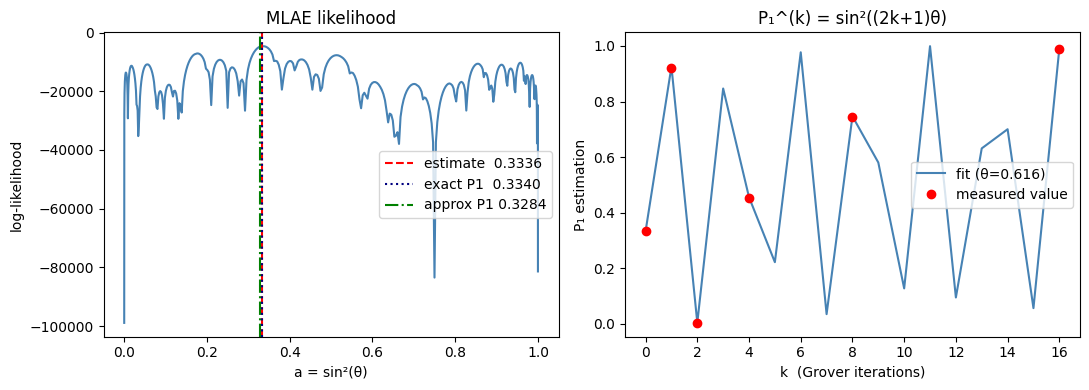

In [18]:
# ============================================================
# 5. 可視化
# ============================================================
theta_grid = np.linspace(1e-4, np.pi / 2 - 1e-4, 400)
ll_grid    = np.array([-neg_log_lik(t) for t in theta_grid])
a_grid     = np.sin(theta_grid)**2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(a_grid, ll_grid, color='steelblue')
axes[0].axvline(a_hat,     color='red',   ls='--',
                label=f'estimate  {a_hat:.4f}')
axes[0].axvline(P1_exact,  color='navy',  ls=':',
                label=f'exact P1  {P1_exact:.4f}')
axes[0].axvline(P1_approx, color='green', ls='-.',
                label=f'approx P1 {P1_approx:.4f}')
axes[0].set_xlabel('a = sin²(θ)')
axes[0].set_ylabel('log-likelihood')
axes[0].set_title('MLAE likelihood')
axes[0].legend()

k_dense      = np.arange(max(k_list) + 1)
P1_fit_dense = np.sin((2 * k_dense + 1) * theta_hat)**2
axes[1].plot(k_dense, P1_fit_dense, '-', color='steelblue',
             label=f'fit (θ={theta_hat:.3f})')
axes[1].plot(k_list, [h / N for h, N in zip(h_list, N_list)],
             'o', color='red', zorder=5, label='measured value')
axes[1].set_xlabel('k  (Grover iterations)')
axes[1].set_ylabel('P₁ estimation')
axes[1].set_title('P₁^(k) = sin²((2k+1)θ)')
axes[1].legend()

plt.tight_layout()
plt.show()

今回の実装が、理論値に非常に近い結果を得られていることがわかります。

## まとめ

ここでは、[Stamatopoulos et al. (2020)](https://quantum-journal.org/papers/q-2020-07-06-291/) で提案されたオプションプライシングアルゴリズムを Qamomile で実装する方法をご紹介しました。
以下にこのページで紹介した重要な情報をまとめます。

* 対数正規分布を Möttönen の符号化手法により量子状態に符号化、一様な制御回転を用いてコールオプションのペイオフをペイオフ量子ビット振幅に符号化しました。状態の読み込みには、Qamomile の `amplitude_encoding` を用いることができます。
* Grover 演算子 $\mathcal{Q}$ を $k$ 回適用した回路を様々な $k$ で測定し、最尤推定から振幅角を推定することで、期待ペイオフを求めました。